In [30]:
import os
import re
import numpy as np
import pandas as pd
from collections import defaultdict

def extract_timestamp(filename):
    """Extract timestamp from filename (e.g., 2d_grain30000.dat -> 30000)."""
    match = re.search(r'2d_grain(\d+)\.dat', filename)
    if match:
        return int(match.group(1))
    return 0

def process_dat_file(file_path):
    """Process a single .dat file to extract grain data."""
    data = []
    with open(file_path, "r") as infile:
        for line in infile:
            columns = line.strip().split()
            try:
                x = int(columns[0])
                y = int(columns[1])
                grain_id = int(float(columns[-4]))
                value = int(columns[-1])
                data.append((x, y, grain_id, value))
            except (ValueError, IndexError):
                continue
    return data

def compute_neighbors_and_areas(grain_grid, max_x, max_y):
    """Compute number of neighbors and average area of neighbors using grain-based approach."""
    # Initialize dictionaries
    grain_neighbors = {}  # grain_id -> set of neighboring grain IDs
    grain_areas = defaultdict(int)  # grain_id -> number of pixels (area)
    
    # Count pixels for each grain (calculate areas)
    for x in range(max_x):
        for y in range(max_y):
            grain_id = grain_grid[x, y]
            if grain_id == -1:
                continue
            
            # Initialize grain_neighbors entry if not exists
            if grain_id not in grain_neighbors:
                grain_neighbors[grain_id] = set()
            
            # Count pixel for grain area
            grain_areas[grain_id] += 1
    
    # Identify grain boundaries and add neighbors
    for x in range(max_x):
        for y in range(max_y):
            grain_id = grain_grid[x, y]
            if grain_id == -1:
                continue
                
            # Check for neighboring grains
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < max_x and 0 <= ny < max_y and grain_grid[nx, ny] != -1:
                    neighbor_grain_id = grain_grid[nx, ny]
                    if neighbor_grain_id != grain_id:
                        grain_neighbors[grain_id].add(neighbor_grain_id)
    
    # Now we have grain_neighbors mapping and grain_areas
    # Calculate neighbor counts and avg_area_of_neighbors for each pixel
    neighbor_counts = {}
    avg_neighbor_area = {}
    
    for x in range(max_x):
        for y in range(max_y):
            grain_id = grain_grid[x, y]
            if grain_id == -1:
                neighbor_counts[(x, y)] = 0
                avg_neighbor_area[(x, y)] = 0
                continue
            
            # Number of neighbors for this grain
            neighbors = grain_neighbors.get(grain_id, set())
            neighbor_count = len(neighbors)
            neighbor_counts[(x, y)] = neighbor_count
            
            # Calculate average area of neighbors
            if neighbor_count > 0:
                total_area = sum(grain_areas[neighbor] for neighbor in neighbors)
                avg_area = total_area / neighbor_count
            else:
                avg_area = 0
            
            avg_neighbor_area[(x, y)] = avg_area
    
    return neighbor_counts, avg_neighbor_area

def process_all_files(input_directory):
    """Process all .dat files in the directory and create a DataFrame."""
    # Collect all files with timestamps
    all_files = [
        (os.path.join(input_directory, f), extract_timestamp(f))
        for f in os.listdir(input_directory) if f.endswith(".dat")
    ]
    
    # Sort files by numeric timestamp
    all_files.sort(key=lambda x: x[1])
    
    all_data = []
    
    for file_path, timestamp in all_files:
        print(f"Processing {file_path} (timestamp: {timestamp})...")
        data = process_dat_file(file_path)
        
        if not data:
            print(f"No valid data found in {file_path}")
            continue
        
        # Determine grid dimensions
        max_x = max(row[0] for row in data) + 1
        max_y = max(row[1] for row in data) + 1
        
        # Create grids
        grain_grid = np.full((max_x, max_y), -1, dtype=int)
        vulnerable_zones = np.zeros((max_x, max_y), dtype=bool)
        
        # Fill grids
        for x, y, grain_id, value in data:
            grain_grid[x, y] = grain_id
            if value == 1:
                vulnerable_zones[x, y] = True
        
        # Compute features
        neighbor_counts, avg_neighbor_area = compute_neighbors_and_areas(grain_grid, max_x, max_y)
        
        # Combine data into rows with timestamp
        for x, y, grain_id, value in data:
            all_data.append({
                'timestamp': timestamp,
                'x': x,
                'y': y,
                'grain_id': grain_id,
                'vulnerable': value,
                'number_of_neighbors': neighbor_counts.get((x, y), 0),
                'avg_area_of_neighbors': avg_neighbor_area.get((x, y), 0)
            })
    
    return pd.DataFrame(all_data)

# Example usage
input_directory = r"D:\Dewetting data\ processed\20_100\output\grain"  # Update with your directory path

# Process files and create DataFrame
df = process_all_files(input_directory)

# Display the first few rows of the DataFrame
print(df.head())


Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain0.dat (timestamp: 0)...
Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain2000.dat (timestamp: 2000)...
Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain4000.dat (timestamp: 4000)...
Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain6000.dat (timestamp: 6000)...
Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain8000.dat (timestamp: 8000)...
Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain10000.dat (timestamp: 10000)...
Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain12000.dat (timestamp: 12000)...
Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain14000.dat (timestamp: 14000)...
Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain16000.dat (timestamp: 16000)...
Processing D:\Dewetting data\ processed\20_100\output\grain\2d_grain18000.dat (timestamp: 18000)...
Processing D:\De

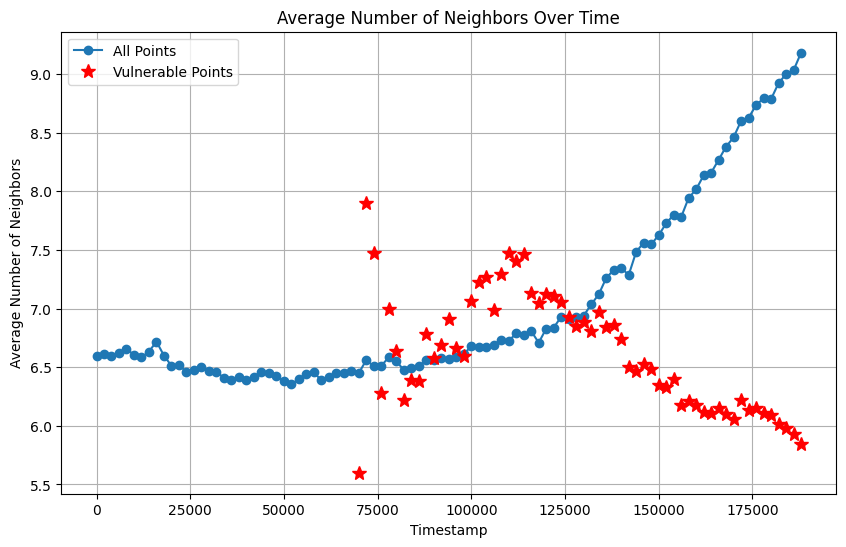

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Group by timestamp and calculate mean number of neighbors
mean_neighbors = df.groupby('timestamp')['number_of_neighbors'].mean()

# Identify timestamps with vulnerable points
vulnerable_timestamps = df[df['vulnerable'] == 1]['timestamp'].unique()

# Calculate average neighbors specifically for vulnerable points
vulnerable_means = df[df['vulnerable'] == 1].groupby('timestamp')['number_of_neighbors'].mean()

# Plot the trend
plt.figure(figsize=(10, 6))
plt.plot(mean_neighbors.index, mean_neighbors.values, marker='o', label='All Points')

# Mark timestamps with vulnerable points
plt.plot(vulnerable_means.index, vulnerable_means.values, 'r*', markersize=10, 
         label='Vulnerable Points')

plt.xlabel('Timestamp')
plt.ylabel('Average Number of Neighbors')
plt.title('Average Number of Neighbors Over Time')
plt.legend()
plt.grid(True)
plt.show()


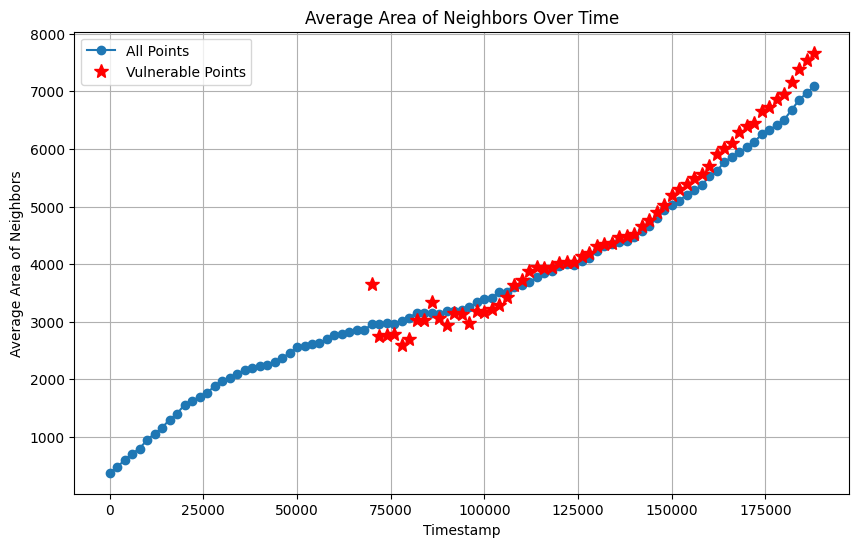

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Group by timestamp and calculate mean area of neighbors
mean_area = df.groupby('timestamp')['avg_area_of_neighbors'].mean()

# Identify timestamps with vulnerable points
vulnerable_timestamps = df[df['vulnerable'] == 1]['timestamp'].unique()

# Calculate average area of neighbors specifically for vulnerable points
vulnerable_areas = df[df['vulnerable'] == 1].groupby('timestamp')['avg_area_of_neighbors'].mean()

# Plot the trend
plt.figure(figsize=(10, 6))
plt.plot(mean_area.index, mean_area.values, marker='o', label='All Points')

# Mark timestamps with vulnerable points
plt.plot(vulnerable_areas.index, vulnerable_areas.values, 'r*', markersize=10, 
         label='Vulnerable Points')

plt.xlabel('Timestamp')
plt.ylabel('Average Area of Neighbors')
plt.title('Average Area of Neighbors Over Time')
plt.legend()
plt.grid(True)
plt.show()


Calculating perimeters...
Processing timestamp: 0
Processing timestamp: 2000
Processing timestamp: 4000
Processing timestamp: 6000
Processing timestamp: 8000
Processing timestamp: 10000
Processing timestamp: 12000
Processing timestamp: 14000
Processing timestamp: 16000
Processing timestamp: 18000
Processing timestamp: 20000
Processing timestamp: 22000
Processing timestamp: 24000
Processing timestamp: 26000
Processing timestamp: 28000
Processing timestamp: 30000
Processing timestamp: 32000
Processing timestamp: 34000
Processing timestamp: 36000
Processing timestamp: 38000
Processing timestamp: 40000
Processing timestamp: 42000
Processing timestamp: 44000
Processing timestamp: 46000
Processing timestamp: 48000
Processing timestamp: 50000
Processing timestamp: 52000
Processing timestamp: 54000
Processing timestamp: 56000
Processing timestamp: 58000
Processing timestamp: 60000
Processing timestamp: 62000
Processing timestamp: 64000
Processing timestamp: 66000
Processing timestamp: 68000
Pr

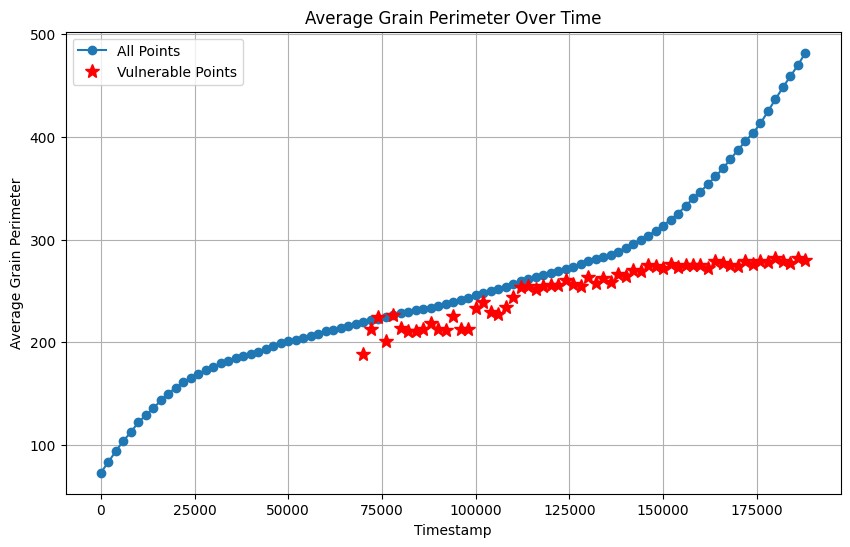

Visualization complete and saved to 'perimeter_over_time.png'


In [33]:
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

def add_perimeter_to_dataframe_optimized(df):
    """Calculate perimeter for each grain using optimized methods."""
    # Create a copy of the DataFrame to avoid modifying the original
    result_df = df.copy()
    
    # Add a new column for perimeter with default value 0
    result_df['perimeter'] = 0
    
    # Process each timestamp separately
    for timestamp in df['timestamp'].unique():
        print(f"Processing timestamp: {timestamp}")
        
        # Get data for this timestamp
        timestamp_data = df[df['timestamp'] == timestamp]
        
        # Get unique grain IDs for this timestamp
        unique_grains = timestamp_data['grain_id'].unique()
        
        # Determine grid dimensions
        max_x = int(timestamp_data['x'].max() + 1)
        max_y = int(timestamp_data['y'].max() + 1)
        
        # Create grain grid more efficiently
        grain_grid = np.full((max_x, max_y), -1, dtype=int)
        
        # This is faster than iterating through rows
        for _, row in timestamp_data[['x', 'y', 'grain_id']].iterrows():
            x, y, grain_id = int(row['x']), int(row['y']), int(row['grain_id'])
            grain_grid[x, y] = grain_id
        
        # Calculate perimeter for each grain
        grain_perimeters = {}
        
        # Process each grain separately
        for grain_id in unique_grains:
            # Create a mask where this grain exists
            grain_mask = (grain_grid == grain_id)
            
            if not np.any(grain_mask):
                grain_perimeters[grain_id] = 0
                continue
            
            # Check the 4 neighbors using slicing operations
            up_diff = grain_mask & (np.pad(grain_grid, ((1, 0), (0, 0)), mode='constant', constant_values=-1)[:-1, :] != grain_id)
            down_diff = grain_mask & (np.pad(grain_grid, ((0, 1), (0, 0)), mode='constant', constant_values=-1)[1:, :] != grain_id)
            left_diff = grain_mask & (np.pad(grain_grid, ((0, 0), (1, 0)), mode='constant', constant_values=-1)[:, :-1] != grain_id)
            right_diff = grain_mask & (np.pad(grain_grid, ((0, 0), (0, 1)), mode='constant', constant_values=-1)[:, 1:] != grain_id)
            
            # A pixel is on the boundary if any of its neighbors is different
            boundary_mask = up_diff | down_diff | left_diff | right_diff
            
            # Count boundary pixels
            perimeter = np.sum(boundary_mask)
            grain_perimeters[grain_id] = perimeter
        
        # Update perimeter values in the DataFrame using efficient mapping
        result_df.loc[result_df['timestamp'] == timestamp, 'perimeter'] = result_df.loc[
            result_df['timestamp'] == timestamp, 'grain_id'
        ].map(lambda x: grain_perimeters.get(x, 0))
    
    return result_df

# Actually call the function to calculate perimeters
print("Calculating perimeters...")
df_with_perimeter = add_perimeter_to_dataframe_optimized(df)
print("Perimeter calculation complete!")

# Show the first few rows to confirm perimeter was added
print("\nDataFrame with perimeter column:")
print(df_with_perimeter.head())

# Plot perimeter trend
print("\nCreating perimeter visualization...")

# Group by timestamp and calculate mean perimeter
mean_perimeter = df_with_perimeter.groupby('timestamp')['perimeter'].mean()

# Plot perimeter trend
plt.figure(figsize=(10, 6))
plt.plot(mean_perimeter.index, mean_perimeter.values, marker='o', label='All Points')

# Add vulnerable points
vulnerable_perimeters = df_with_perimeter[df_with_perimeter['vulnerable'] == 1].groupby('timestamp')['perimeter'].mean()
plt.plot(vulnerable_perimeters.index, vulnerable_perimeters.values, 'r*', markersize=10, 
         label='Vulnerable Points')

plt.xlabel('Timestamp')
plt.ylabel('Average Grain Perimeter')
plt.title('Average Grain Perimeter Over Time')
plt.legend()
plt.grid(True)
plt.savefig('perimeter_over_time.png')  # Save the figure to a file
plt.show()

print("Visualization complete and saved to 'perimeter_over_time.png'")


In [34]:
def create_grain_level_df(pixel_df):
    """Convert pixel-level DataFrame to grain-level DataFrame."""
    # Group by timestamp and grain_id
    grouped = pixel_df.groupby(['timestamp', 'grain_id'])
    
    # Calculate grain area (number of pixels)
    area_df = grouped.size().rename('area')
    
    # Aggregate grain-level features (take first since all values are the same within grain)
    grain_df = grouped.agg({
        'perimeter': 'first',
        'avg_area_of_neighbors': 'first',
        'number_of_neighbors': 'first',
        'vulnerable': 'mean',  # Proportion of vulnerable pixels in the grain
    }).join(area_df)
    
    # Add derived metrics
    grain_df['circularity'] = 4 * np.pi * grain_df['area'] / np.maximum(grain_df['perimeter']**2, 1)
    
    # Add binary vulnerability flag (1 if any pixel in grain is vulnerable)
    grain_df['is_vulnerable'] = (grain_df['vulnerable'] > 0).astype(int)
    
    # Reset index for easier access
    grain_df = grain_df.reset_index()
    
    return grain_df

# Create grain-level DataFrame
grain_df = create_grain_level_df(df_with_perimeter)

# Display the result
print(grain_df.head())


   timestamp  grain_id  perimeter  avg_area_of_neighbors  number_of_neighbors  \
0          0        10         56             376.400000                    5   
1          0        27         97             329.142857                    7   
2          0        38         27             305.000000                    5   
3          0        45         90             304.000000                    8   
4          0        51         75             444.285714                    7   

   vulnerable  area  circularity  is_vulnerable  
0         0.0   273     1.093947              0  
1         0.0   364     0.486147              0  
2         0.0    82     1.413501              0  
3         0.0   715     1.109254              0  
4         0.0   538     1.201904              0  


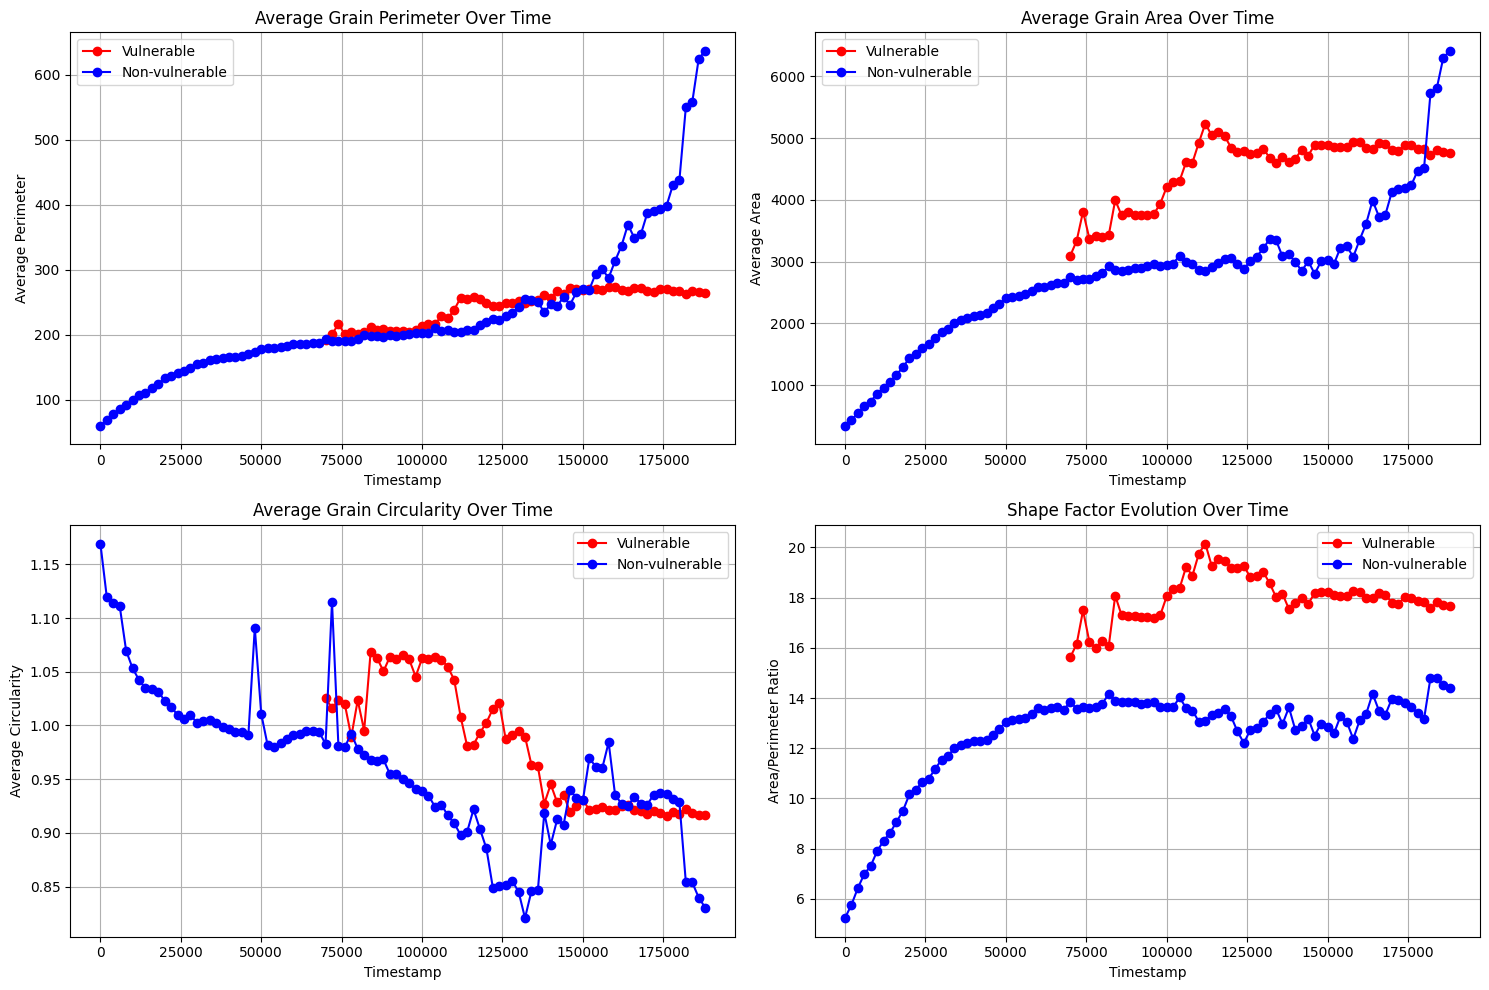

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# First, create a grain-level DataFrame from the pixel-level data
def create_grain_level_df(pixel_df):
    """Convert pixel-level DataFrame to grain-level DataFrame."""
    # Group by timestamp and grain_id
    grouped = pixel_df.groupby(['timestamp', 'grain_id'])
    
    # Calculate grain area (number of pixels)
    area_df = grouped.size().rename('area')
    
    # Aggregate grain-level features
    grain_df = grouped.agg({
        'perimeter': 'first',
        'avg_area_of_neighbors': 'first',
        'number_of_neighbors': 'first',
        'vulnerable': 'mean'  # Proportion of vulnerable pixels in grain
    }).join(area_df)
    
    # Add derived metrics
    grain_df['circularity'] = 4 * np.pi * grain_df['area'] / np.maximum(grain_df['perimeter']**2, 1)
    grain_df['area_perimeter_ratio'] = grain_df['area'] / np.maximum(grain_df['perimeter'], 1)
    
    # Add binary vulnerability flag
    grain_df['is_vulnerable'] = (grain_df['vulnerable'] > 0).astype(int)
    
    return grain_df.reset_index()

# Create grain-level DataFrame
grain_df = create_grain_level_df(df_with_perimeter)

# Time series visualization with vulnerability comparison
plt.figure(figsize=(15, 10))

# Plot 1: Average Perimeter Over Time
plt.subplot(2, 2, 1)
vuln_perimeter = grain_df[grain_df['is_vulnerable'] == 1].groupby('timestamp')['perimeter'].mean()
nonvuln_perimeter = grain_df[grain_df['is_vulnerable'] == 0].groupby('timestamp')['perimeter'].mean()

plt.plot(vuln_perimeter.index, vuln_perimeter.values, 'r-o', label='Vulnerable')
plt.plot(nonvuln_perimeter.index, nonvuln_perimeter.values, 'b-o', label='Non-vulnerable')
plt.xlabel('Timestamp')
plt.ylabel('Average Perimeter')
plt.title('Average Grain Perimeter Over Time')
plt.legend()
plt.grid(True)

# Plot 2: Average Area Over Time
plt.subplot(2, 2, 2)
vuln_area = grain_df[grain_df['is_vulnerable'] == 1].groupby('timestamp')['area'].mean()
nonvuln_area = grain_df[grain_df['is_vulnerable'] == 0].groupby('timestamp')['area'].mean()

plt.plot(vuln_area.index, vuln_area.values, 'r-o', label='Vulnerable')
plt.plot(nonvuln_area.index, nonvuln_area.values, 'b-o', label='Non-vulnerable')
plt.xlabel('Timestamp')
plt.ylabel('Average Area')
plt.title('Average Grain Area Over Time')
plt.legend()
plt.grid(True)

# Plot 3: Average Circularity Over Time
plt.subplot(2, 2, 3)
vuln_circ = grain_df[grain_df['is_vulnerable'] == 1].groupby('timestamp')['circularity'].mean()
nonvuln_circ = grain_df[grain_df['is_vulnerable'] == 0].groupby('timestamp')['circularity'].mean()

plt.plot(vuln_circ.index, vuln_circ.values, 'r-o', label='Vulnerable')
plt.plot(nonvuln_circ.index, nonvuln_circ.values, 'b-o', label='Non-vulnerable')
plt.xlabel('Timestamp')
plt.ylabel('Average Circularity')
plt.title('Average Grain Circularity Over Time')
plt.legend()
plt.grid(True)

# Plot 4: Area/Perimeter Ratio Over Time
plt.subplot(2, 2, 4)
vuln_ratio = grain_df[grain_df['is_vulnerable'] == 1].groupby('timestamp')['area_perimeter_ratio'].mean()
nonvuln_ratio = grain_df[grain_df['is_vulnerable'] == 0].groupby('timestamp')['area_perimeter_ratio'].mean()

plt.plot(vuln_ratio.index, vuln_ratio.values, 'r-o', label='Vulnerable')
plt.plot(nonvuln_ratio.index, nonvuln_ratio.values, 'b-o', label='Non-vulnerable')
plt.xlabel('Timestamp')
plt.ylabel('Area/Perimeter Ratio')
plt.title('Shape Factor Evolution Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('grain_properties_over_time.png')
plt.show()


In [36]:
grain_df.to_csv(r'grain_df_20_100.csv', index=False)